# Human Capital Analysis Notebook

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Update these paths to match your folder structure
DATA_DIR = "C:/Users/Gorata/IndabaX/Data_Clean"

In [24]:
hcp_df = pd.read_csv(f"{DATA_DIR}/human_capital_dataset.csv")

In [25]:
hcp_df.head()

,Year,BWA_education,BWA_life_expectancy,KEN_education,KEN_life_expectancy,NAM_education,NAM_life_expectancy,ZAF_education,ZAF_life_expectancy,ZWE_education,...,KEN_FAO_CP_23014,NAM_FAO_CP_23012,NAM_FAO_CP_23013,NAM_FAO_CP_23014,ZAF_FAO_CP_23012,ZAF_FAO_CP_23013,ZAF_FAO_CP_23014,ZWE_FAO_CP_23012,ZWE_FAO_CP_23013,ZWE_FAO_CP_23014
0,2001,7.48678,52.210,2.88300,56.501,7.40270,51.980,NaN,57.161,NaN,...,7.878677,41.239459,35.208023,9.424651,48.680144,37.246317,5.371810,90.419642,92.069590,1.866212
1,2002,7.80341,52.373,2.87672,56.759,6.05017,51.988,NaN,55.580,NaN,...,2.602176,48.545440,40.524090,15.036091,53.302185,43.724882,17.334486,91.272041,93.756278,1.832022
2,2003,9.07960,52.851,NaN,57.369,6.39103,51.918,NaN,54.245,NaN,...,13.191143,52.009717,44.191891,9.301030,56.329442,47.294785,8.426041,92.124441,95.442967,1.799062
3,2004,9.56878,53.573,2.96267,57.947,NaN,52.175,NaN,53.963,NaN,...,15.948863,54.161168,44.623376,0.978517,55.939620,47.968487,1.425693,92.976840,97.129655,1.767267
4,2005,9.23078,54.386,3.00100,58.510,7.10705,52.557,NaN,53.914,NaN,...,13.693719,55.397096,45.213940,1.326474,57.093572,48.778461,1.689938,93.829240,98.816343,1.736576


In [26]:
hcp_df.columns

Index(['Year', 'BWA_education', 'BWA_life_expectancy', 'KEN_education',
       'KEN_life_expectancy', 'NAM_education', 'NAM_life_expectancy',
       'ZAF_education', 'ZAF_life_expectancy', 'ZWE_education',
       'ZWE_life_expectancy', 'BWA_FAO_CP_23012', 'BWA_FAO_CP_23013',
       'BWA_FAO_CP_23014', 'KEN_FAO_CP_23012', 'KEN_FAO_CP_23013',
       'KEN_FAO_CP_23014', 'NAM_FAO_CP_23012', 'NAM_FAO_CP_23013',
       'NAM_FAO_CP_23014', 'ZAF_FAO_CP_23012', 'ZAF_FAO_CP_23013',
       'ZAF_FAO_CP_23014', 'ZWE_FAO_CP_23012', 'ZWE_FAO_CP_23013',
       'ZWE_FAO_CP_23014'],
      dtype='object')

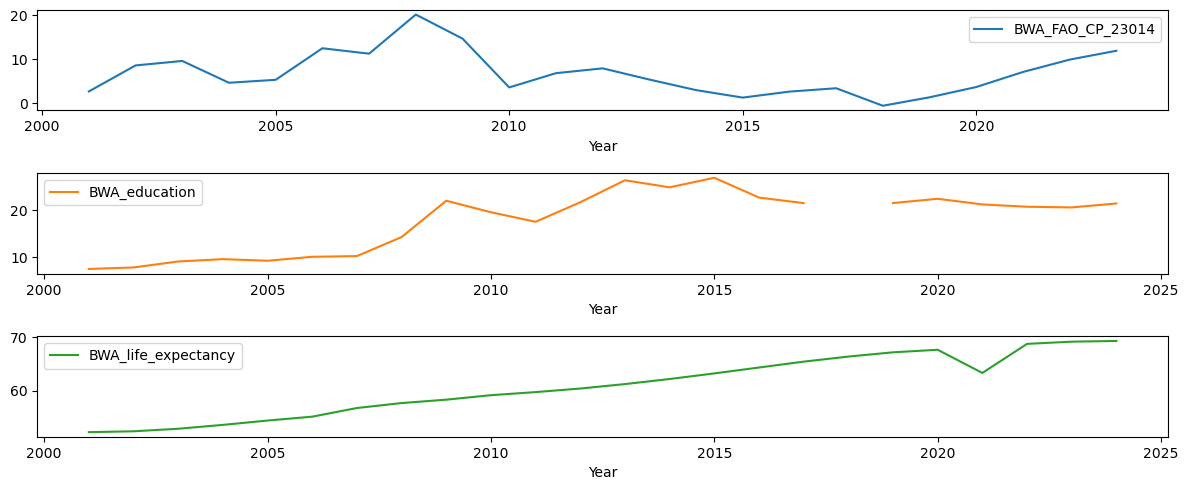

In [27]:
# Inspect time series
hcp_df.plot(x="Year", y=["BWA_FAO_CP_23014", "BWA_education", "BWA_life_expectancy"], subplots=True, layout=(3, 1), figsize=(12, 5), sharex=False)

plt.tight_layout()

plt.savefig(r'C:/Users/Gorata/IndabaX/HCP_Images/time_series.png')

plt.show()

## Regression Analysis

In [28]:
hcp_df = hcp_df.dropna(subset=["BWA_education"])
hcp_df = hcp_df.dropna(subset=["BWA_FAO_CP_23014"])

In [29]:
import statsmodels.api as sm

# Define dependent variable
y = hcp_df["BWA_FAO_CP_23014"]

# Define independent variables
X = hcp_df[
    [
        "BWA_education",
        "BWA_life_expectancy"
    ]
]

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       BWA_FAO_CP_23014   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.9099
Date:                Sat, 25 Jul 2026   Prob (F-statistic):              0.419
Time:                        14:26:25   Log-Likelihood:                -64.216
No. Observations:                  22   AIC:                             134.4
Df Residuals:                      19   BIC:                             137.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.9974    

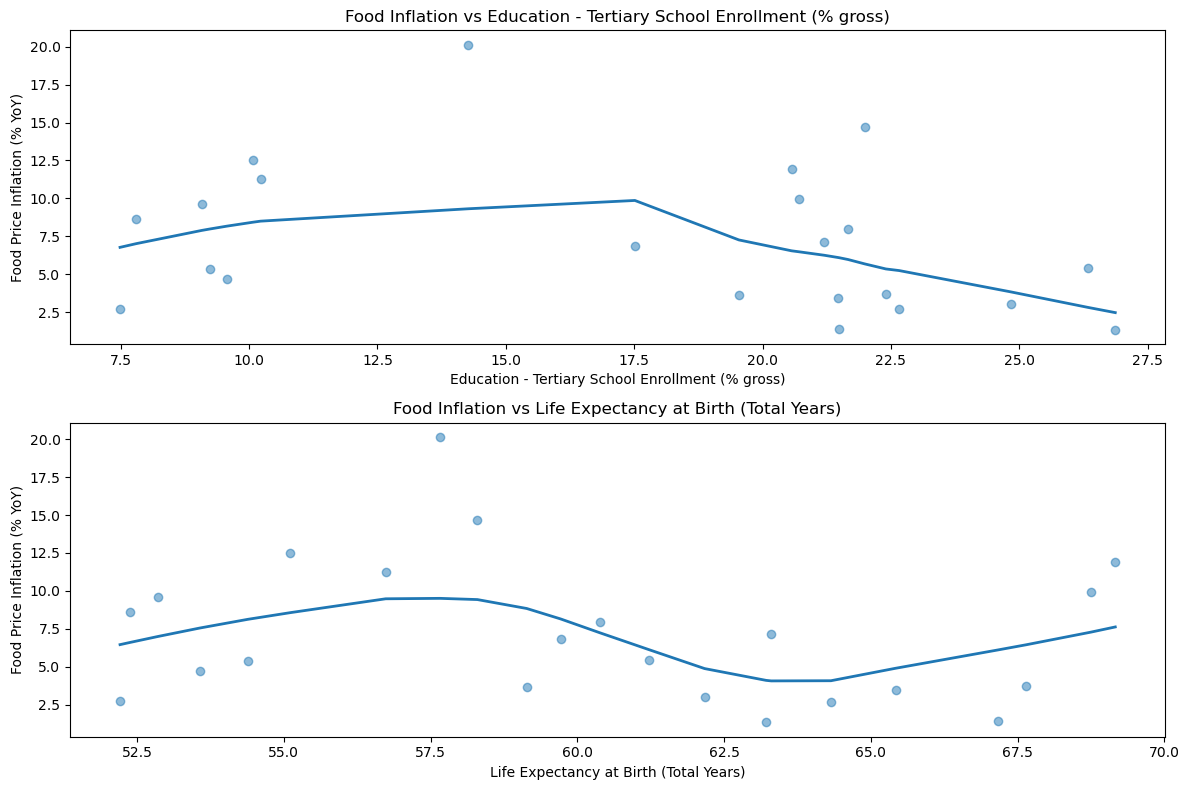

In [30]:
# Plot lowess plots
features = [
    "BWA_education",
    "BWA_life_expectancy"
]

# Display names for plots
feature_labels = {
    "BWA_education": "Education - Tertiary School Enrollment (% gross)",
    "BWA_life_expectancy": "Life Expectancy at Birth (Total Years)"
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.regplot(
        data=hcp_df,
        x=feature,
        y="BWA_FAO_CP_23014",
        lowess=True,
        scatter_kws={"alpha": 0.5},
        line_kws={"linewidth": 2},
        ax=ax
    )

    ax.set_title(f"Food Inflation vs {feature_labels[feature]}")
    ax.set_xlabel(feature_labels[feature])
    ax.set_ylabel("Food Price Inflation (% YoY)")

plt.tight_layout()
plt.savefig(r'C:/Users/Gorata/IndabaX/HCP_Images/lowess_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## Granger Causality Test

In [31]:
from statsmodels.tsa.stattools import grangercausalitytests

def granger_summary(data, cause, effect, max_lag=2):

    # Keep only the two variables and remove missing values
    test_data = data[[effect, cause]].dropna()

    # Run Granger causality test
    results = grangercausalitytests(
        test_data,
        maxlag=max_lag,
        verbose=False
    )

    summary = []

    for lag in range(1, max_lag + 1):

        f_stat = results[lag][0]["ssr_ftest"][0]
        p_value = results[lag][0]["ssr_ftest"][1]

        summary.append({
            "Cause": cause,
            "Effect": effect,
            "Lag": lag,
            "F-statistic": f_stat,
            "p-value": p_value
        })

    return pd.DataFrame(summary)

In [33]:
# Granger Causality test for Education
education_results = granger_summary(
    hcp_df,
    cause="BWA_education",
    effect="BWA_FAO_CP_23014",
    max_lag=3
)

education_results

,Cause,Effect,Lag,F-statistic,p-value
0,BWA_education,BWA_FAO_CP_23014,1,6.324802,0.021626
1,BWA_education,BWA_FAO_CP_23014,2,3.604406,0.052692
2,BWA_education,BWA_FAO_CP_23014,3,1.854304,0.191152


In [34]:
# Granger Causality test for life expectancy
life_results = granger_summary(
    hcp_df,
    cause="BWA_life_expectancy",
    effect="BWA_FAO_CP_23014",
    max_lag=3
)

life_results

,Cause,Effect,Lag,F-statistic,p-value
0,BWA_life_expectancy,BWA_FAO_CP_23014,1,0.528884,0.476430
1,BWA_life_expectancy,BWA_FAO_CP_23014,2,0.262162,0.772839
2,BWA_life_expectancy,BWA_FAO_CP_23014,3,0.326935,0.805971


In [35]:
# Combine the results
granger_results = pd.concat(
    [education_results, life_results],
    ignore_index=True
)

print(granger_results)

                 Cause            Effect  Lag  F-statistic   p-value
0        BWA_education  BWA_FAO_CP_23014    1     6.324802  0.021626
1        BWA_education  BWA_FAO_CP_23014    2     3.604406  0.052692
2        BWA_education  BWA_FAO_CP_23014    3     1.854304  0.191152
3  BWA_life_expectancy  BWA_FAO_CP_23014    1     0.528884  0.476430
4  BWA_life_expectancy  BWA_FAO_CP_23014    2     0.262162  0.772839
5  BWA_life_expectancy  BWA_FAO_CP_23014    3     0.326935  0.805971


In [36]:
# Add a significance column

granger_results["Conclusion"] = granger_results["p-value"].apply(
    lambda p: "Reject H₀" if p < 0.05 else "Fail to reject H₀"
)

granger_results

,Cause,Effect,Lag,F-statistic,p-value,Conclusion
0,BWA_education,BWA_FAO_CP_23014,1,6.324802,0.021626,Reject H₀
1,BWA_education,BWA_FAO_CP_23014,2,3.604406,0.052692,Fail to reject H₀
2,BWA_education,BWA_FAO_CP_23014,3,1.854304,0.191152,Fail to reject H₀
3,BWA_life_expectancy,BWA_FAO_CP_23014,1,0.528884,0.476430,Fail to reject H₀
4,BWA_life_expectancy,BWA_FAO_CP_23014,2,0.262162,0.772839,Fail to reject H₀
5,BWA_life_expectancy,BWA_FAO_CP_23014,3,0.326935,0.805971,Fail to reject H₀


## Forward Projections

In [51]:
# Forecast education
import statsmodels.api as sm

# Prepare education data
edu_df = hcp_df[
    ["Year", "BWA_education"]
].dropna()

# Independent variable
X_edu = edu_df[["Year"]]

# Add constant
X_edu = sm.add_constant(X_edu)

# Dependent variable
y_edu = edu_df["BWA_education"]

# Fit OLS
edu_model = sm.OLS(y_edu, X_edu).fit()

print(edu_model.summary())

                            OLS Regression Results                            
Dep. Variable:          BWA_education   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     33.95
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           1.06e-05
Time:                        18:51:56   Log-Likelihood:                -61.029
No. Observations:                  22   AIC:                             126.1
Df Residuals:                      20   BIC:                             128.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1509.4261    262.074     -5.760      0.0

In [52]:
# Create future years
future_years = pd.DataFrame({
    "Year": np.arange(
        hcp_df["Year"].max() + 1,
        hcp_df["Year"].max() + 6
    )
})

In [53]:
# Predict future education + confidence intervals
X_future_edu = future_years[["Year"]]

X_future_edu = sm.add_constant(X_future_edu)

edu_predictions = edu_model.get_prediction(
    X_future_edu
)

edu_summary = edu_predictions.summary_frame(alpha=0.05)

future_years["BWA_education"] = edu_summary["mean"]

future_years["Education_Lower_CI"] = (
    edu_summary["mean_ci_lower"]
)

future_years["Education_Upper_CI"] = (
    edu_summary["mean_ci_upper"]
)

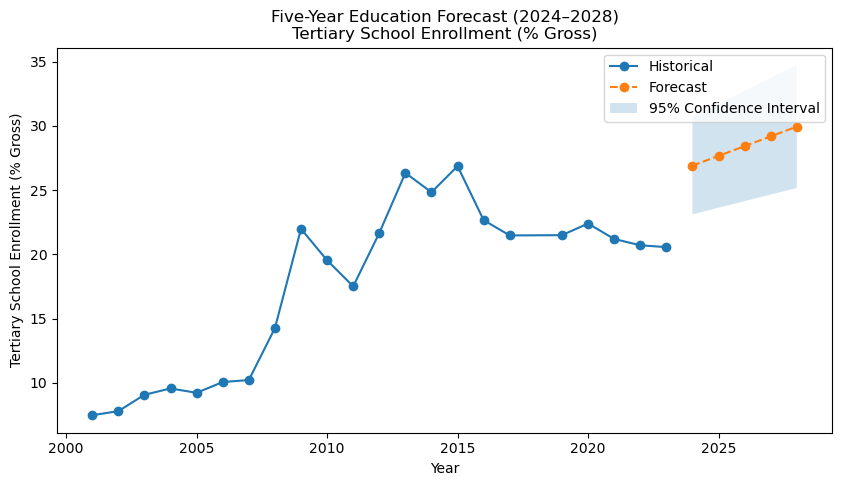

In [54]:
# Education forecast with confidence intervals
plt.figure(figsize=(10,5))

# Historical education
plt.plot(
    hcp_df["Year"],
    hcp_df["BWA_education"],
    marker="o",
    label="Historical"
)

# Forecast education
plt.plot(
    future_years["Year"],
    future_years["BWA_education"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    future_years["Year"],
    future_years["Education_Lower_CI"],
    future_years["Education_Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Year")
plt.ylabel("Tertiary School Enrollment (% Gross)")
plt.title(
    "Five-Year Education Forecast (2024–2028)\n"
    "Tertiary School Enrollment (% Gross)"
)

plt.legend()

plt.savefig(
    r'C:/Users/Gorata/IndabaX/HCP_Images/five_year_education_prediction.png',
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
# Forecast life expectancy

# Prepare life expectancy data
life_df = hcp_df[
    ["Year", "BWA_life_expectancy"]
].dropna()

X_life = life_df[["Year"]]

X_life = sm.add_constant(X_life)

y_life = life_df["BWA_life_expectancy"]

# Fit OLS
life_model = sm.OLS(y_life, X_life).fit()

print(life_model.summary())

                             OLS Regression Results                            
Dep. Variable:     BWA_life_expectancy   R-squared:                       0.962
Model:                             OLS   Adj. R-squared:                  0.960
Method:                  Least Squares   F-statistic:                     508.1
Date:                 Sat, 25 Jul 2026   Prob (F-statistic):           1.09e-15
Time:                         18:57:27   Log-Likelihood:                -32.133
No. Observations:                   22   AIC:                             68.27
Df Residuals:                       20   BIC:                             70.45
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1528.2294     70.469    -21.68

In [56]:
# Predict future life expectancy + confidence intervals
X_future_life = future_years[["Year"]]

X_future_life = sm.add_constant(X_future_life)

life_predictions = life_model.get_prediction(
    X_future_life
)

life_summary = life_predictions.summary_frame(alpha=0.05)

future_years["BWA_life_expectancy"] = life_summary["mean"]

future_years["Life_Lower_CI"] = (
    life_summary["mean_ci_lower"]
)

future_years["Life_Upper_CI"] = (
    life_summary["mean_ci_upper"]
)

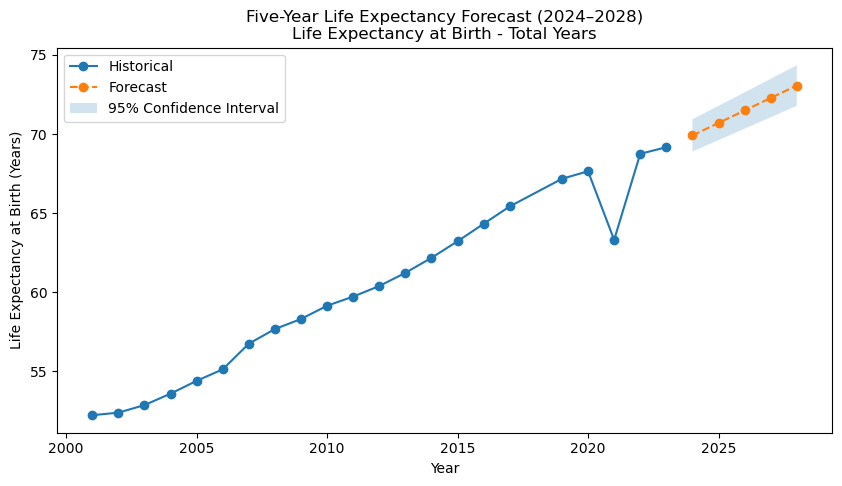

In [58]:
# Plot life expectancy forecast with confidence intervals

plt.figure(figsize=(10,5))

# Historical life expectancy
plt.plot(
    hcp_df["Year"],
    hcp_df["BWA_life_expectancy"],
    marker="o",
    label="Historical"
)

# Forecast life expectancy
plt.plot(
    future_years["Year"],
    future_years["BWA_life_expectancy"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    future_years["Year"],
    future_years["Life_Lower_CI"],
    future_years["Life_Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Year")
plt.ylabel("Life Expectancy at Birth (Years)")
plt.title(
    "Five-Year Life Expectancy Forecast (2024–2028)\n"
    "Life Expectancy at Birth - Total Years"
)

plt.legend()

plt.savefig(
    r'C:/Users/Gorata/IndabaX/HCP_Images/five_year_life_expectancy_prediction.png',
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
# Predict food inflation using education and life expectancy
# Fit food inflation model

food_df = hcp_df[
    [
        "BWA_FAO_CP_23014",
        "BWA_education",
        "BWA_life_expectancy"
    ]
].dropna()


y_food = food_df["BWA_FAO_CP_23014"]

X_food = food_df[
    [
        "BWA_education",
        "BWA_life_expectancy"
    ]
]

X_food = sm.add_constant(X_food)


food_model = sm.OLS(
    y_food,
    X_food
).fit()


print(food_model.summary())

                            OLS Regression Results                            
Dep. Variable:       BWA_FAO_CP_23014   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.9099
Date:                Sat, 25 Jul 2026   Prob (F-statistic):              0.419
Time:                        19:13:52   Log-Likelihood:                -64.216
No. Observations:                  22   AIC:                             134.4
Df Residuals:                      19   BIC:                             137.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.9974    

In [60]:
# Forecast food inflation

X_future_food = future_years[
    [
        "BWA_education",
        "BWA_life_expectancy"
    ]
]

X_future_food = sm.add_constant(
    X_future_food
)


food_predictions = food_model.get_prediction(
    X_future_food
)

food_summary = food_predictions.summary_frame(alpha=0.05)


future_years["Predicted_food_inflation"] = (
    food_summary["mean"]
)

future_years["Food_Lower_CI"] = (
    food_summary["mean_ci_lower"]
)

future_years["Food_Upper_CI"] = (
    food_summary["mean_ci_upper"]
)

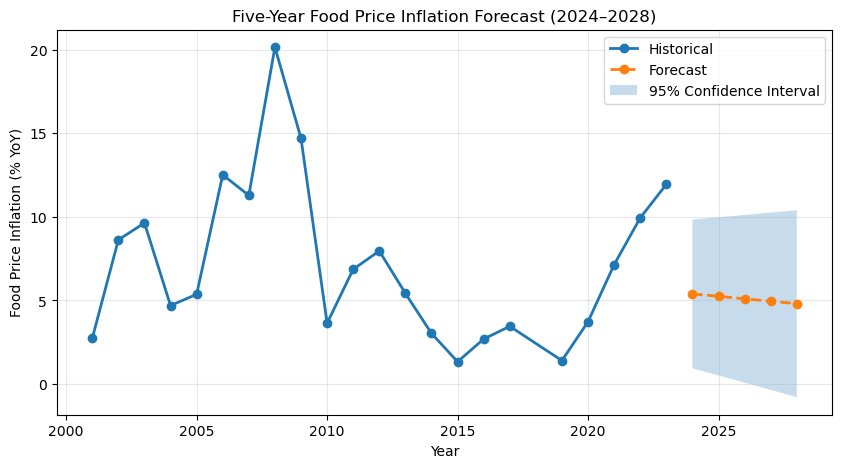

In [61]:
# Plot food inflation forecast with confidence interval
plt.figure(figsize=(10, 5))

# Historical food inflation
plt.plot(
    hcp_df["Year"],
    hcp_df["BWA_FAO_CP_23014"],
    marker="o",
    linewidth=2,
    label="Historical"
)

# Forecast food inflation
plt.plot(
    future_years["Year"],
    future_years["Predicted_food_inflation"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

# 95% Confidence Interval
plt.fill_between(
    future_years["Year"],
    future_years["Food_Lower_CI"],
    future_years["Food_Upper_CI"],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.xlabel("Year")
plt.ylabel("Food Price Inflation (% YoY)")
plt.title("Five-Year Food Price Inflation Forecast (2024–2028)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    r"C:/Users/Gorata/IndabaX/HCP_Images/five_year_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()